In [1]:
import esigmapy
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

No version information file '.version' found


In [2]:
mean_anomaly_array = np.linspace(-np.pi, np.pi, 50)

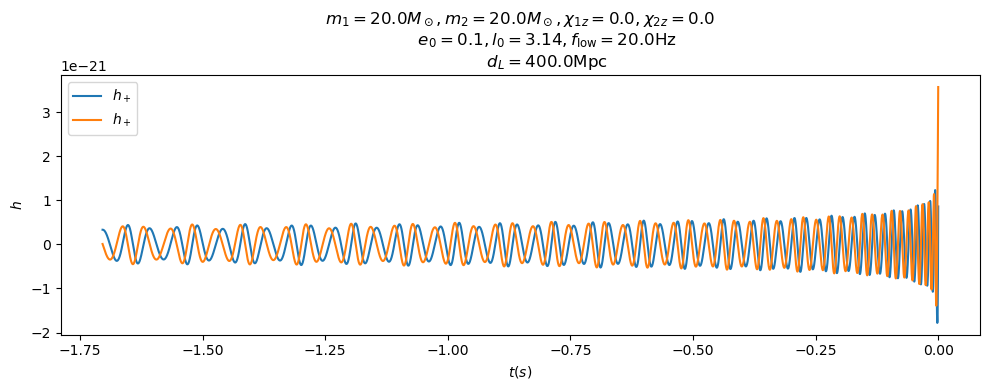

In [3]:
m1 = 20.
m2 = 20.
spin1z = 0.0
spin2z = 0.0
eccentricity = 0.1
mean_anomaly = np.pi
modes_to_use = [(2,2)]

distance = 400.

f_low = 20. 
delta_t = 1/2**14

ref_mode = esigmapy.get_inspiral_esigma_modes(mass1=m1, 
                                        mass2=m2,
                                        spin1z=spin1z, 
                                        spin2z=spin2z,
                                        eccentricity=eccentricity,
                                        mean_anomaly=mean_anomaly,
                                        distance=distance,
                                        f_lower=f_low,
                                        delta_t=delta_t,
                                        include_conjugate_modes=False,
                                        modes_to_use=modes_to_use)

ref_signal = ref_mode[(2,2)]

plt.figure(figsize=(10,4))
plt.title(fr"""$m_1={m1} M_\odot, m_2={m2} M_\odot, \chi_{{1z}}={spin1z}, \chi_{{2z}}={spin2z}$ 
          $e_0={eccentricity}, l_0={mean_anomaly:.2f}, f_{{\rm{{low}}}}={f_low}\rm{{Hz}}$
          $d_L={distance}\rm{{Mpc}}$""")
ref_signal.plot(label=r"$h_+$")
plt.xlabel(r"$t (s)$")
plt.ylabel(r"$h$")
plt.legend()
plt.tight_layout()

In [4]:
ref_time = list(ref_signal.sample_times)

X_waveform = np.zeros((len(mean_anomaly_array), len(ref_time)), dtype=complex)

for i, mean_anomaly in enumerate(mean_anomaly_array):
    test_modes = esigmapy.get_inspiral_esigma_modes(
        mass1=m1, mass2=m2,
        spin1z=spin1z, spin2z=spin2z,
        eccentricity=eccentricity, mean_anomaly=mean_anomaly,
        distance=distance,
        f_lower=f_low, delta_t=delta_t,
        modes_to_use=modes_to_use
    )
    
    signal = test_modes[(2,2)]
    test_time = list(signal.sample_times)

    signal_amp = np.abs(signal)
    signal_phase = np.unwrap(np.angle(signal))
    
    amp_spline = CubicSpline(test_time, signal_amp)
    test_sample_amp = amp_spline(ref_time)
    phase_spline = CubicSpline(test_time, signal_phase)
    test_sample_phase = phase_spline(ref_time)
    
    test_sample_phase = test_sample_phase - test_sample_phase[0]

    test_sample_aligned = test_sample_amp * np.exp(1j * test_sample_phase)
    
    X_waveform[i, :] = test_sample_aligned

In [5]:
U, s, Vt = np.linalg.svd(X_waveform, full_matrices=False)

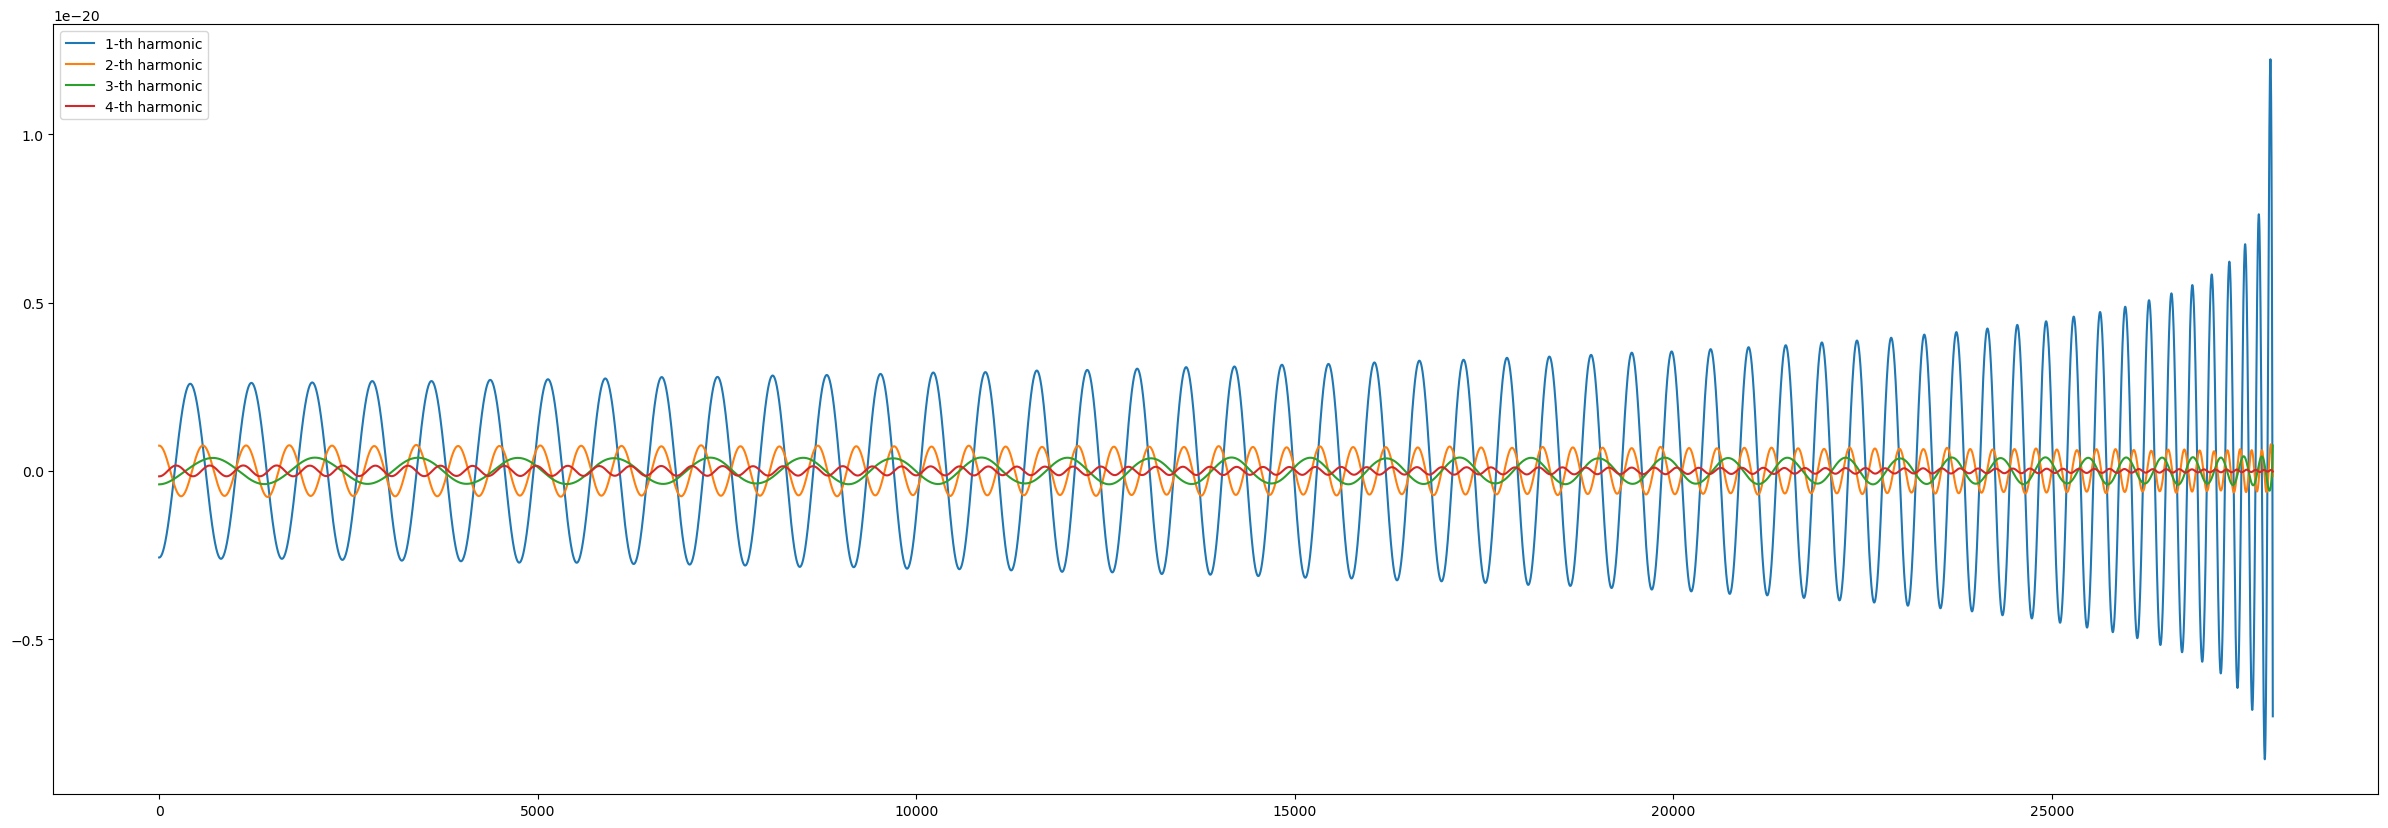

In [6]:
plt.figure(figsize=(30, 10))

for i in range(1,5):
        waveform = s[i-1] * Vt[i-1]
        plt.plot(waveform.real, label=f'{i}-th harmonic')

plt.legend()
plt.show()

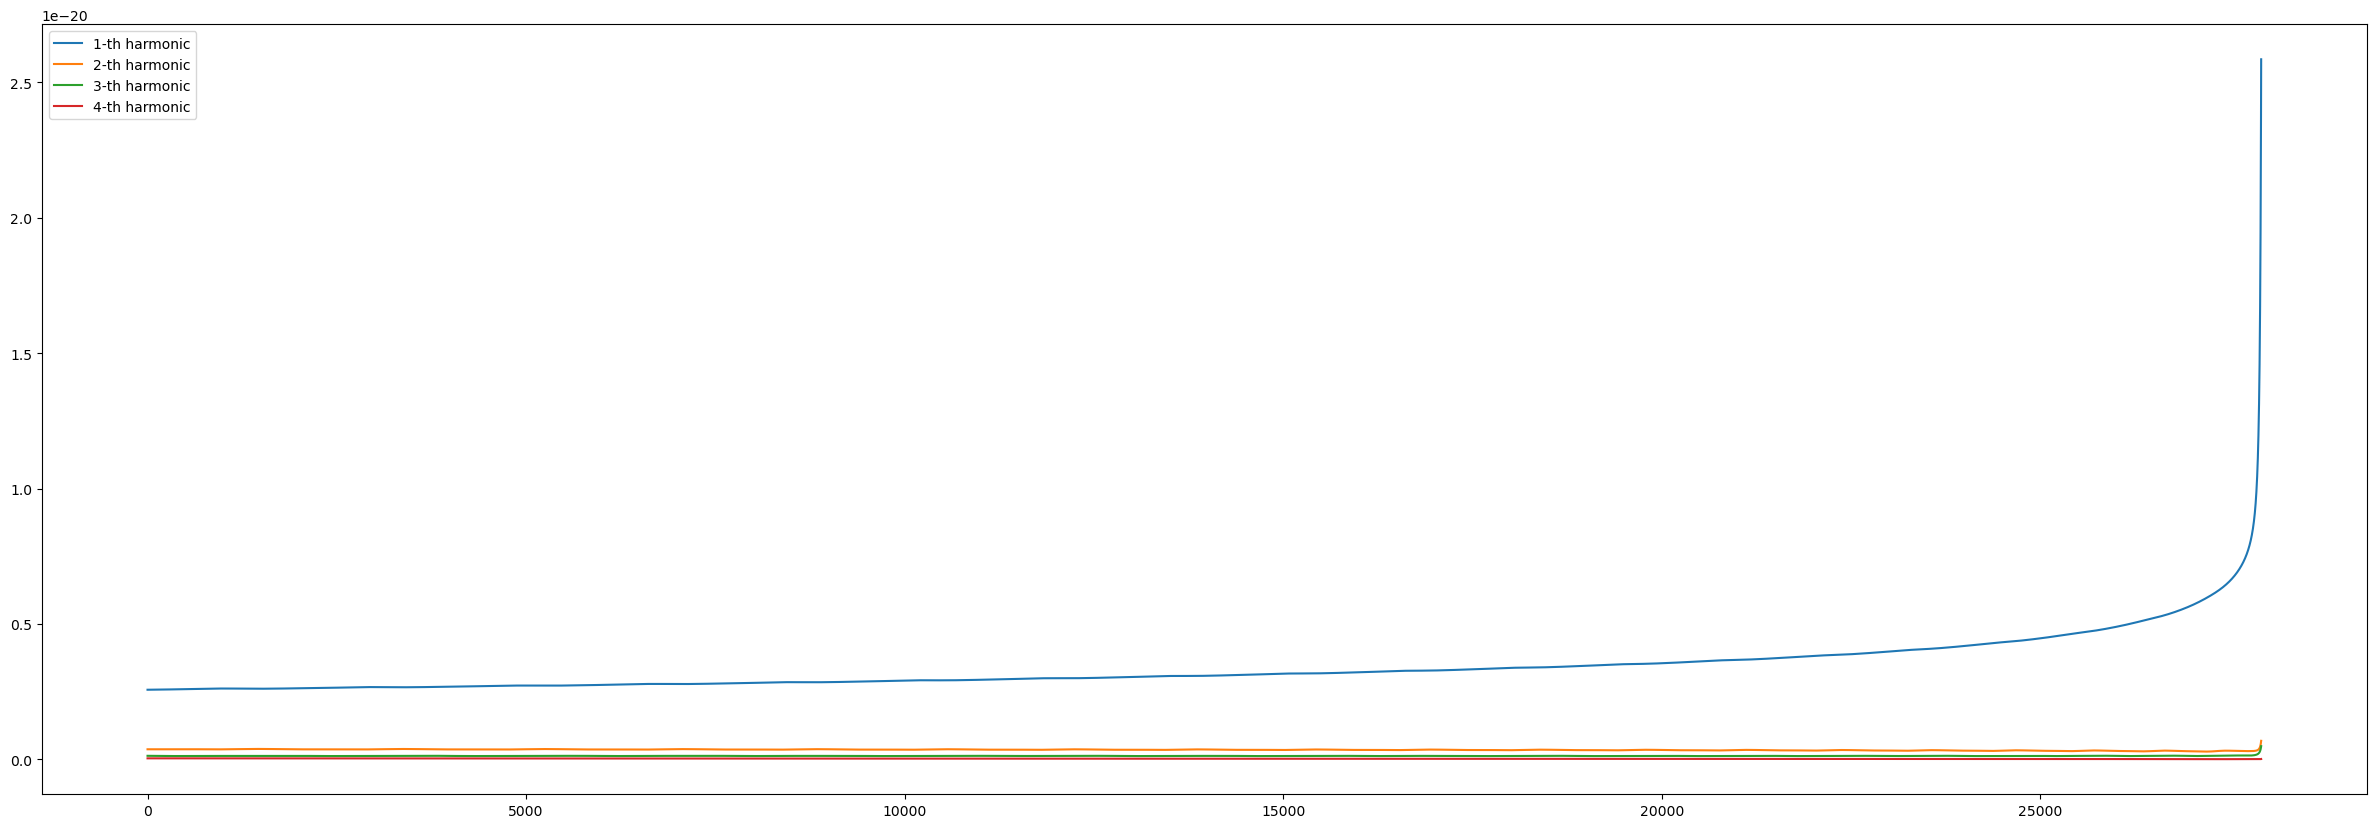

In [7]:
plt.figure(figsize=(30, 10))

for i in range(1,5):
        amp = np.abs(s[i-1] * Vt[i-1])
        plt.plot(1/i * amp, label=f'{i}-th harmonic')

plt.legend()
plt.show()

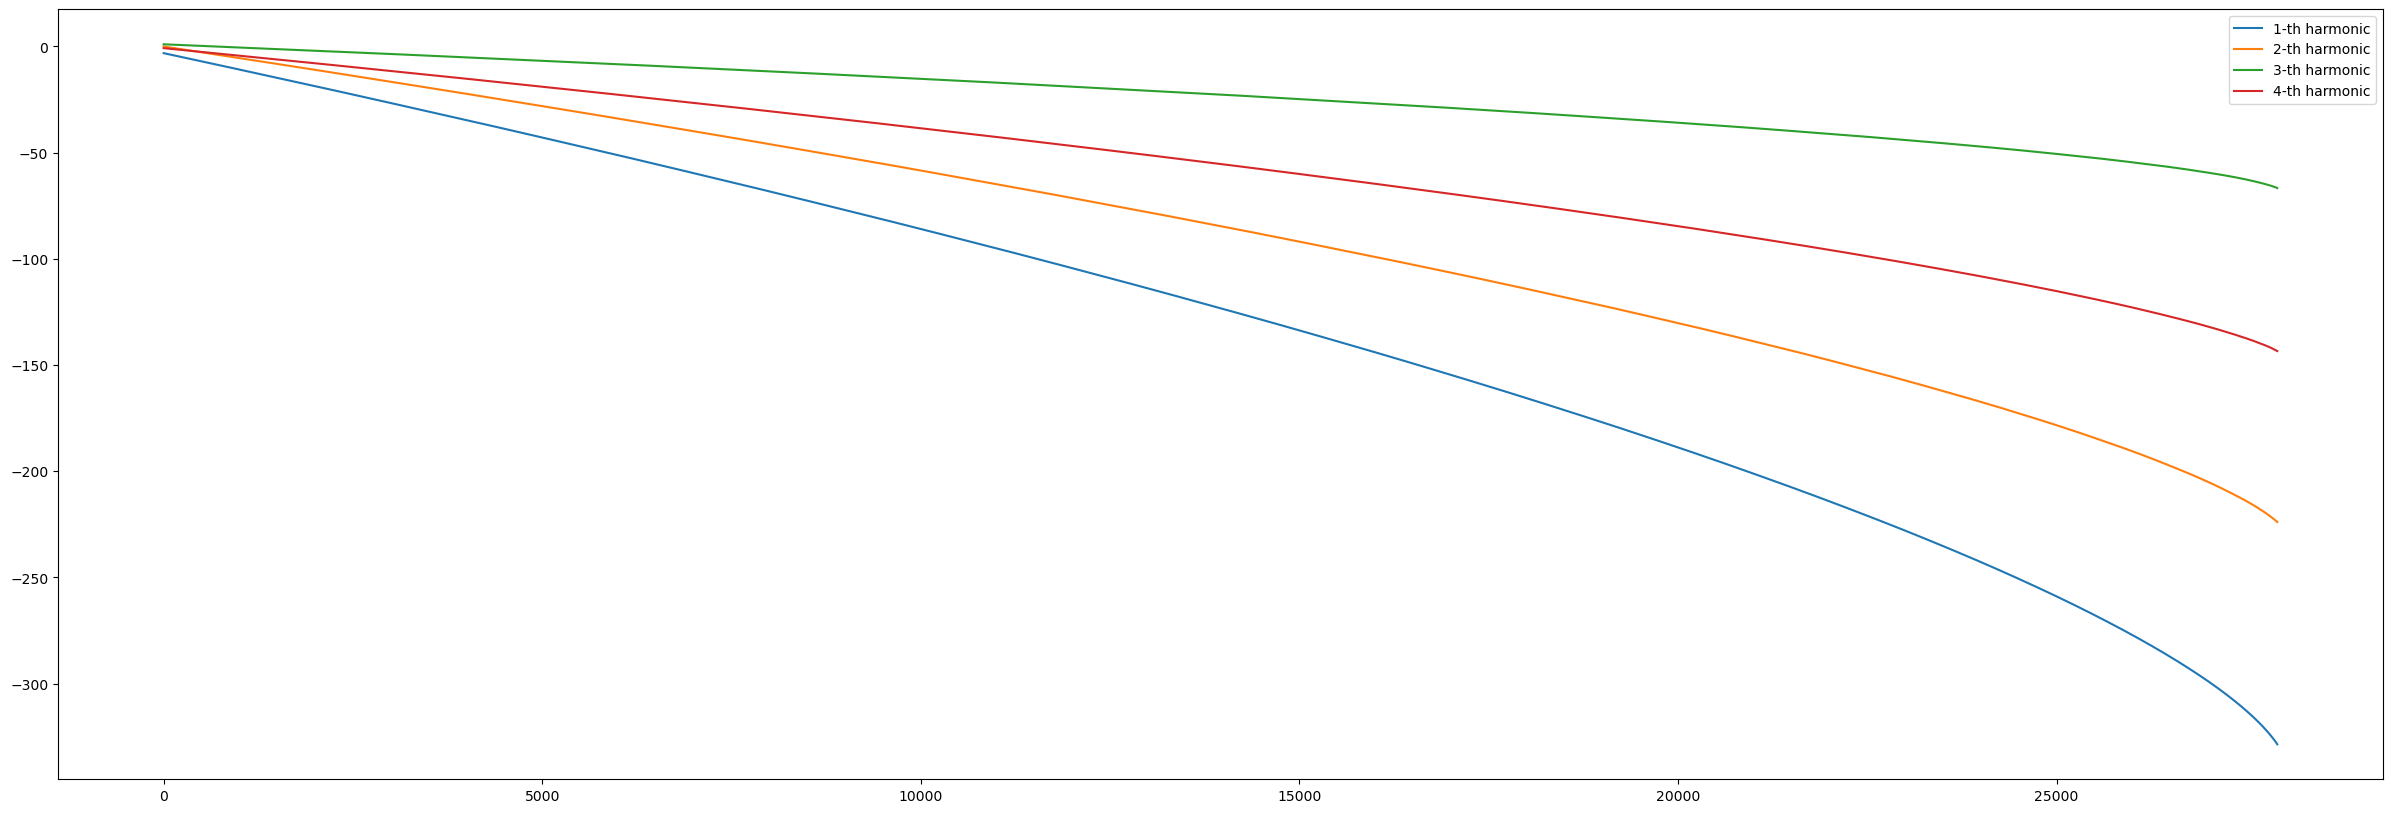

In [8]:
plt.figure(figsize=(30, 10))

for i in range(1,5):
        phase = np.unwrap(np.angle(s[i-1] * Vt[i-1]))
        plt.plot(1/i * phase, label=f'{i}-th harmonic')

plt.legend()
plt.show()